# Кластеризація. Частина 3: Методи на основі щільності

## Вступ

Кластеризація на основі щільності - це підхід, який групує точки даних на основі їх щільності в просторі ознак. На відміну від методів розбиття, таких як k-means, кластеризація на основі щільності може:

- **Знаходити кластери довільних форм** (не лише сферичні)
- **Ідентифікувати шум та викиди** автоматично
- **Визначати кількість кластерів** автоматично
- **Обробляти кластери з різною щільністю** (з деякими обмеженнями)

Основна ідея полягає в тому, що кластери є щільними областями точок даних, розділеними розрідженими областями. Це робить методи на основі щільності особливо корисними для реальних наборів даних, де кластери можуть мати неправильні форми або містити шум.

## Алгоритм DBSCAN

**DBSCAN** (Кластеризація на основі щільності просторових застосувань з шумом, Density-Based Spatial Clustering of Applications with Noise) - найпопулярніший алгоритм кластеризації на основі щільності. Він був розроблений Естером та ін. у 1996 році і залишається широко використовуваним сьогодні.

### Ключові концепції

#### 1. ε-околиця
ε-околиця точки p визначається як:
$$N_{\varepsilon}(p) = \{q \in D | \text{dist}(p,q) \leq \varepsilon\}$$

Де:
- $D$ - набір даних
- $\text{dist}(p,q)$ - відстань між точками p та q
- $\varepsilon$ - радіус (параметр)

#### 2. Параметр MinPts
MinPts - мінімальна кількість точок, необхідна для формування щільної області. Він визначає чи є область щільною чи розрідженою.

#### 3. Класифікація точок

**Основна точка**: Точка p є основною точкою, якщо:
$$|N_{\varepsilon}(p)| \geq \text{MinPts}$$

**Гранична точка**: Точка q є граничною точкою, якщо:
- Вона не є основною точкою
- Вона знаходиться на відстані ε від принаймні однієї основної точки

**Точка шуму**: Точка, яка не є ні основною, ні граничною точкою.

![Типи точок](images/8.0-Point-types.jpg)

[Джерело зображення](https://www.researchgate.net/publication/315326812_In-line_recognition_of_agglomerated_pharmaceutical_pellets_with_density-based_clustering_and_convolutional_neural_network)

### Кроки алгоритму DBSCAN

1. **Ініціалізація**: Позначити всі точки як невідвідані
2. **Для кожної невідвіданої точки p**:
   - Позначити p як відвідану
   - Якщо p є основною точкою:
     - Створити новий кластер C
     - Додати p до C
     - Додати всі точки в N_ε(p) до множини потенційних сусідів (seed set)
     - Для кожної точки q у множині потенційних сусідів:
       - Якщо q невідвідана, позначити як відвідану
       - Якщо q є основною точкою, додати N_ε(q) до множини потенційних сусідів
       - Якщо q ще не призначена до жодного кластера, додати q до C
   - Якщо p не є основною точкою, позначити як шум (якщо вона не стане граничною точкою пізніше)

### Ключові властивості

- **Довільні форми**: Може знаходити кластери будь-якої форми, не лише сферичні
- **Обробка шуму**: Автоматично ідентифікує та позначає точки шуму
- **Автоматична кількість кластерів**: Визначає кількість кластерів автоматично
- **На основі щільності**: Кластери є щільними областями, розділеними розрідженими областями

## DBSCAN vs K-Means: Ключові відмінності

| Аспект | K-Means | DBSCAN |
|--------|---------|---------|
| **Форма кластера** | Лише сферична | Довільні форми |
| **Кількість кластерів** | Потрібно визначити k | Визначається автоматично |
| **Обробка шуму** | Призначає всі точки до кластерів | Ідентифікує шум/викиди |
| **Чутливість до параметрів** | Чутлива до ініціалізації | Чутлива до ε та MinPts |
| **Масштабованість** | Добре для великих наборів даних | Може бути повільнішою для дуже великих наборів даних |
| **Щільність кластера** | Припускає подібні щільності | Може обробляти різні щільності |
| **Обробка викидів** | Додає викиди до кластерів | Позначає викиди як шум |

### Коли використовувати DBSCAN

**Використовуйте DBSCAN коли:**
- Ви не знаєте кількість кластерів
- Кластери можуть мати неправильні форми
- Вам потрібно ідентифікувати шум/викиди
- У вас різні щільності кластерів
- Ви хочете автоматичне відкриття кластерів

**Уникайте DBSCAN коли:**
- Вам потрібні сферичні кластери
- У вас високовимірні дані (прокляття розмірності)
- Вам потрібна дуже швидка кластеризація
- Всі точки повинні бути призначені до кластерів

## Практична реалізація з Scikit-Learn

Давайте реалізуємо DBSCAN, використовуючи scikit-learn, та дослідимо його поведінку на різних наборах даних. Ми почнемо з імпорту необхідних бібліотек та створення деяких зразкових наборів даних.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs, make_circles, make_moons

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
np.random.seed(42)

X_moons, y_moons = make_moons(n_samples=300, noise=0.1, random_state=42)

X_circles, y_circles = make_circles(n_samples=300, noise=0.1, factor=0.3, random_state=42)

X_blobs, y_blobs = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
noise = np.random.uniform(-6, 6, (20, 2))
X_blobs = np.vstack([X_blobs, noise])
y_blobs = np.hstack([y_blobs, [-1] * 20])

print("Створено три різні набори даних:")
print(f"   Місяці: {X_moons.shape[0]} точок")
print(f"   Кола: {X_circles.shape[0]} точок") 
print(f"   Краплі з шумом: {X_blobs.shape[0]} точок")

Створено три різні набори даних:
   Місяці: 300 точок
   Кола: 300 точок
   Краплі з шумом: 320 точок


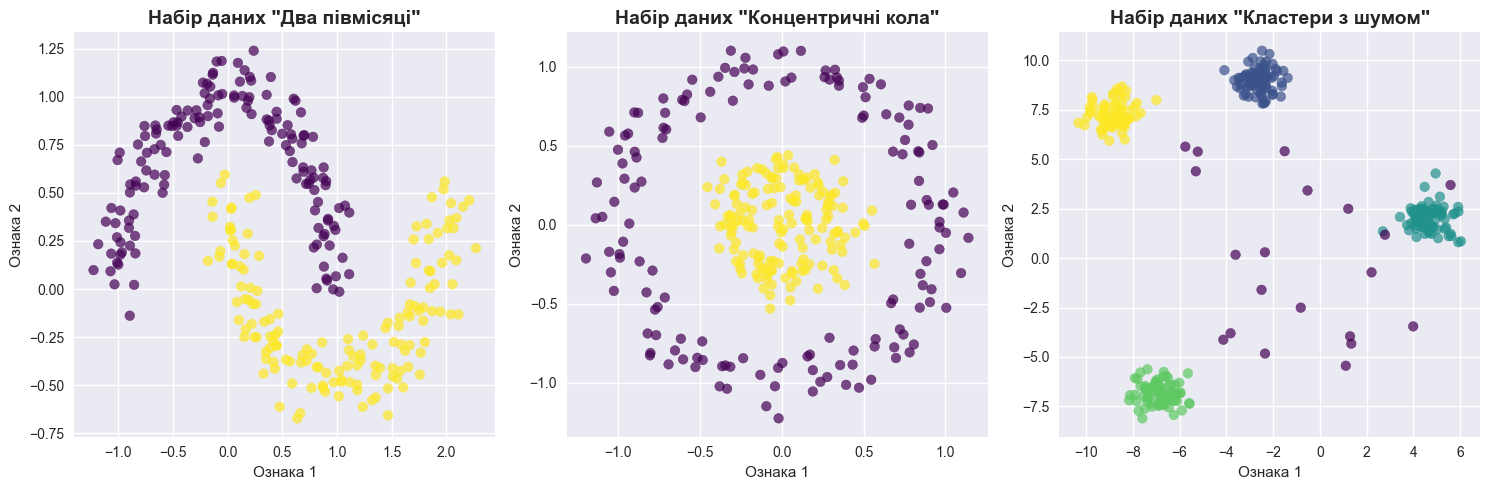

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(X_moons[:, 0], X_moons[:, 1], c=y_moons, cmap='viridis', alpha=0.7)
axes[0].set_title('Набір даних "Два півмісяці"', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Ознака 1')
axes[0].set_ylabel('Ознака 2')

axes[1].scatter(X_circles[:, 0], X_circles[:, 1], c=y_circles, cmap='viridis', alpha=0.7)
axes[1].set_title('Набір даних "Концентричні кола"', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Ознака 1')
axes[1].set_ylabel('Ознака 2')

scatter = axes[2].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_blobs, cmap='viridis', alpha=0.7)
axes[2].set_title('Набір даних "Кластери з шумом"', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Ознака 1')
axes[2].set_ylabel('Ознака 2')

plt.tight_layout()
plt.show()

In [4]:
def apply_dbscan_and_visualize(X, eps, min_samples, title, true_labels=None):
    """
    Застосовує DBSCAN і візуалізує результати
    """
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    cluster_labels = dbscan.fit_predict(X)
    
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)
    
    plt.figure(figsize=(12, 5))
    
    if true_labels is not None:
        plt.subplot(1, 2, 1)
        scatter = plt.scatter(X[:, 0], X[:, 1], c=true_labels, cmap='viridis', alpha=0.7)
        plt.title(f'Справжні мітки\n{title}', fontsize=12, fontweight='bold')
        plt.xlabel('Ознака 1')
        plt.ylabel('Ознака 2')
    
    plt.subplot(1, 2, 2)
    unique_labels = set(cluster_labels)
    colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))
    
    for k, col in zip(unique_labels, colors):
        if k == -1:
            col = 'black'
            marker = 'x'
            size = 50
            alpha = 0.8
        else:
            marker = 'o'
            size = 30
            alpha = 0.7
            
        class_member_mask = (cluster_labels == k)
        xy = X[class_member_mask]
        plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, alpha=alpha)
    
    plt.title(f'Результати DBSCAN\nε={eps}, MinPts={min_samples}\nКластерів: {n_clusters}, Шуму: {n_noise}', 
              fontsize=12, fontweight='bold')
    plt.xlabel('Ознака 1')
    plt.ylabel('Ознака 2')
    
    plt.tight_layout()
    plt.show()
    
    return cluster_labels, n_clusters, n_noise

Перевірка DBSCAN на датасеті 'місяці'

Перевірка з ε = 0.1, MinPts = 4


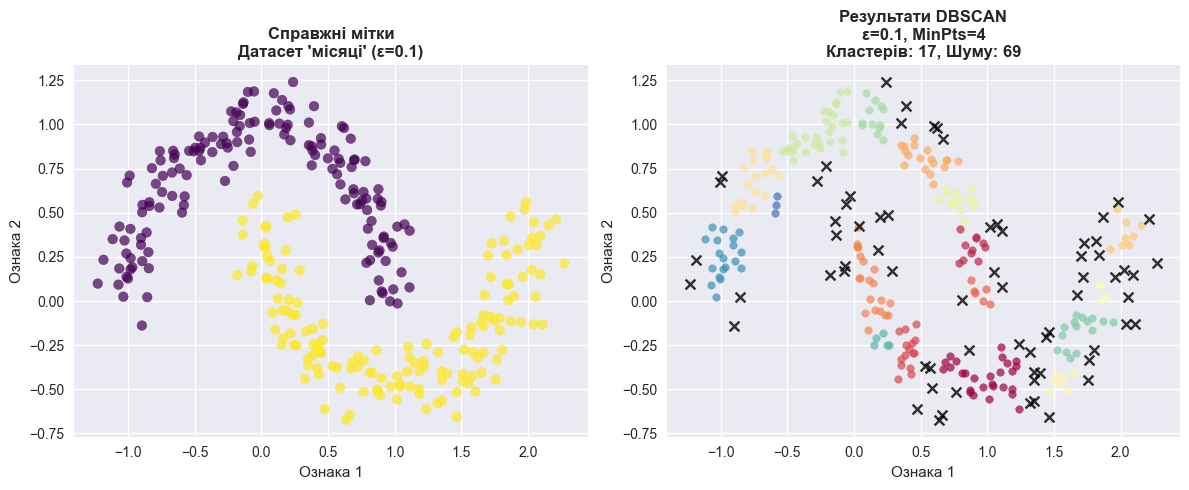

   Знайдено 17 кластерів і 69 шумових точок

Перевірка з ε = 0.2, MinPts = 4


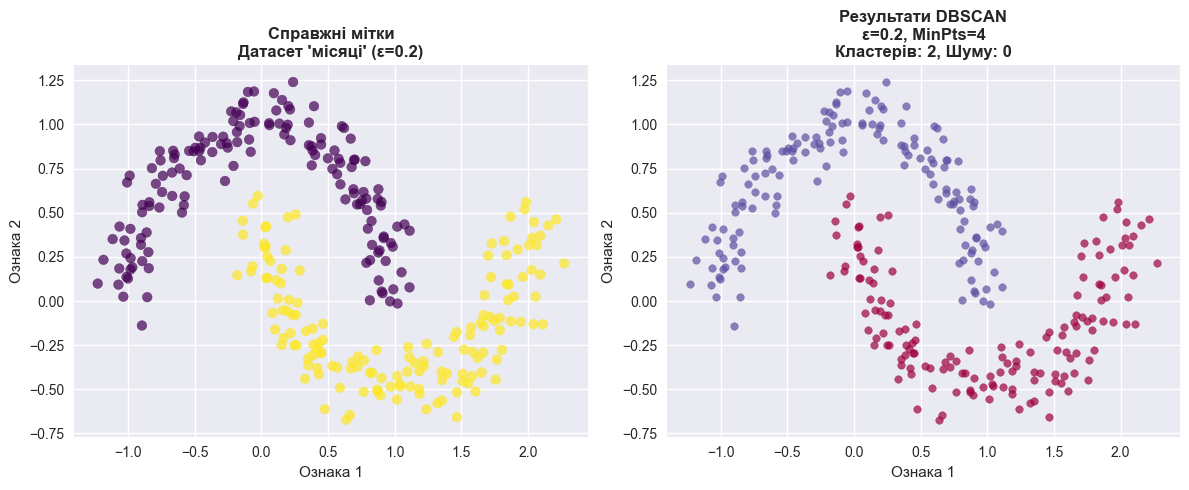

   Знайдено 2 кластерів і 0 шумових точок

Перевірка з ε = 0.3, MinPts = 4


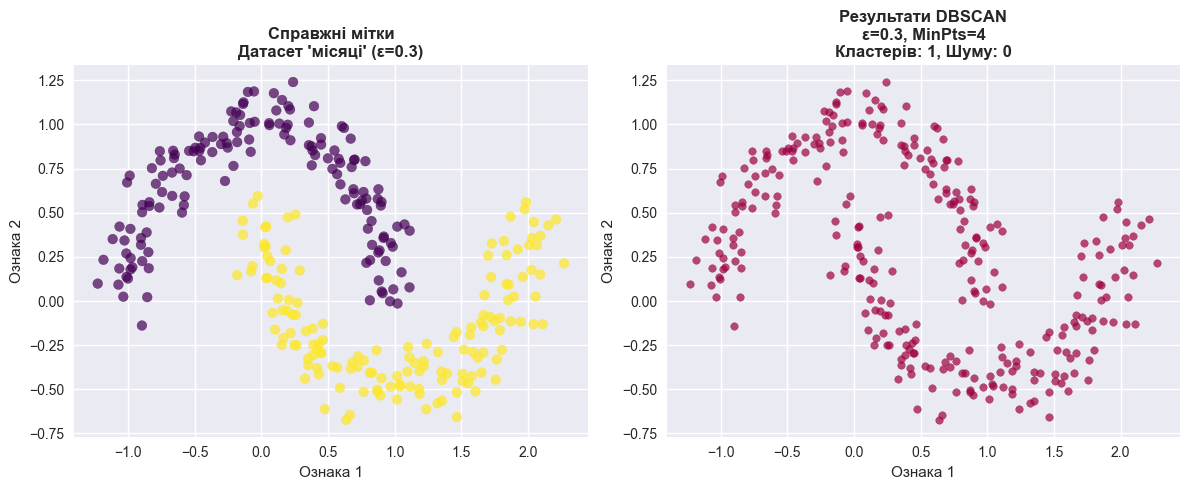

   Знайдено 1 кластерів і 0 шумових точок

Перевірка з ε = 0.4, MinPts = 4


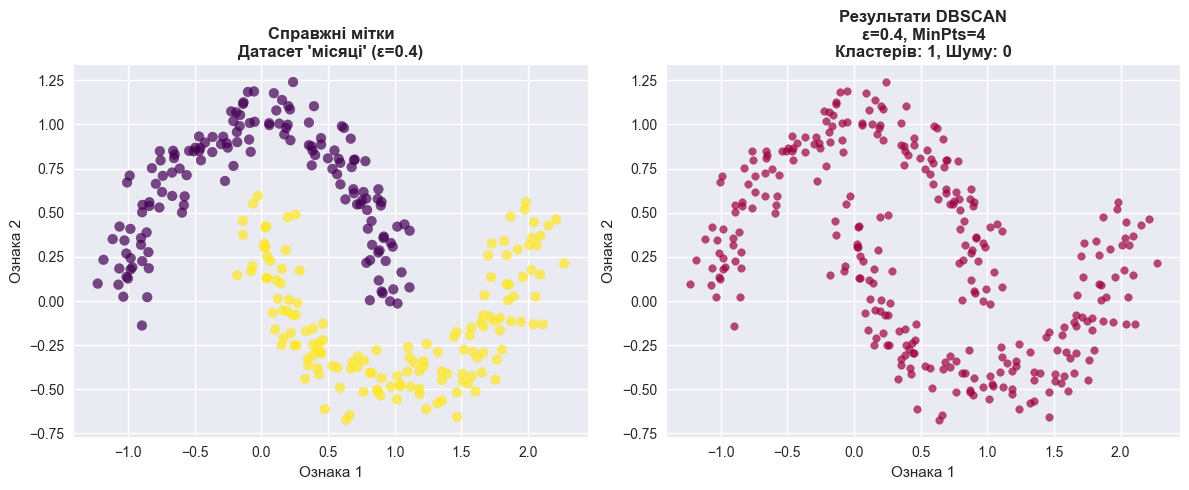

   Знайдено 1 кластерів і 0 шумових точок


In [5]:
print("Перевірка DBSCAN на датасеті 'місяці'")
print("=" * 50)

eps_values = [0.1, 0.2, 0.3, 0.4]

for eps in eps_values:
    print(f"\nПеревірка з ε = {eps}, MinPts = 4")
    labels, n_clusters, n_noise = apply_dbscan_and_visualize(
        X_moons, eps, 4, f"Датасет 'місяці' (ε={eps})", y_moons
    )
    print(f"   Знайдено {n_clusters} кластерів і {n_noise} шумових точок")


Перевірка DBSCAN на датасеті 'кільця'

Перевірка з ε = 0.1, MinPts = 4


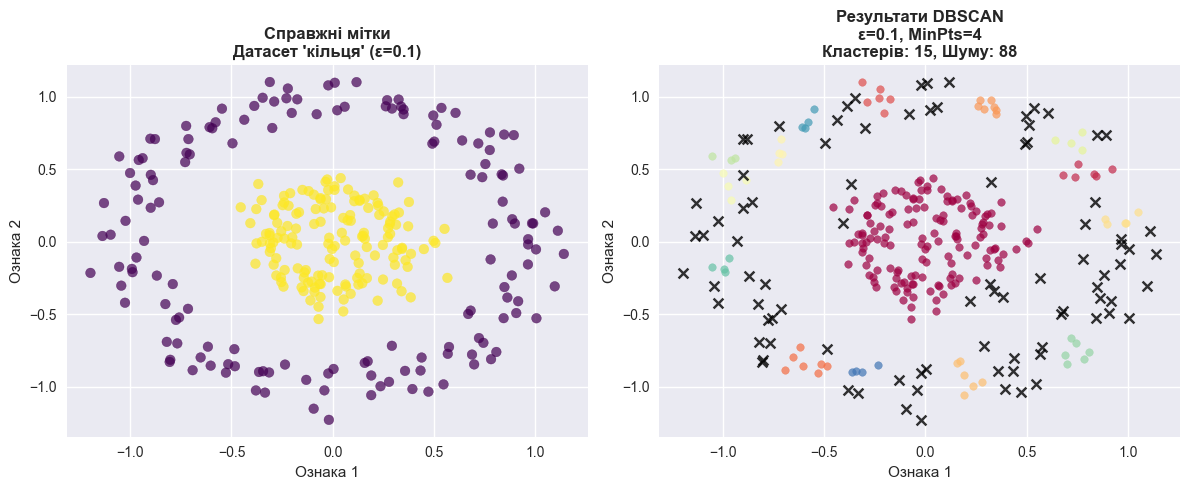

   Знайдено 15 кластерів і 88 шумових точок

Перевірка з ε = 0.2, MinPts = 4


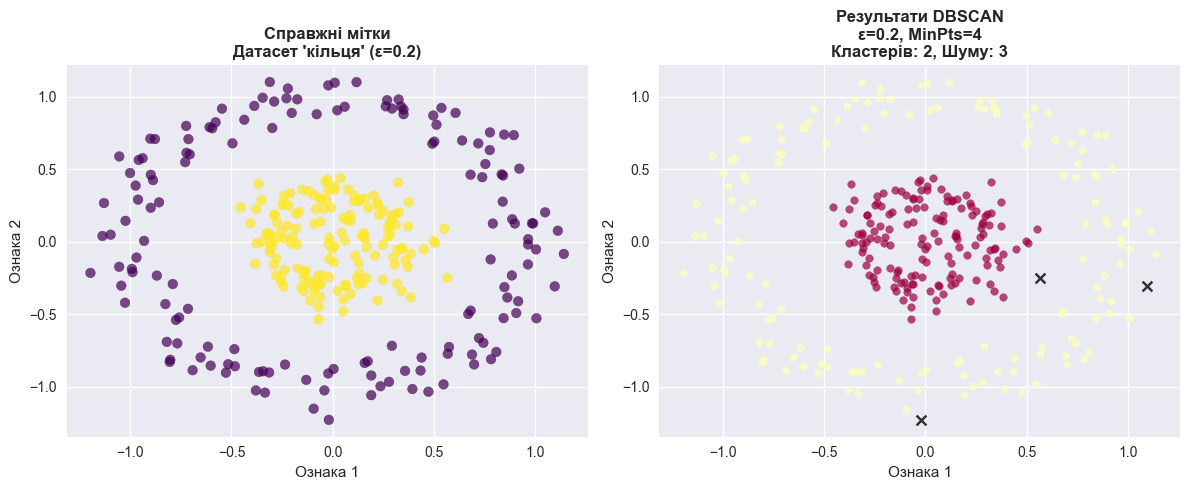

   Знайдено 2 кластерів і 3 шумових точок

Перевірка з ε = 0.3, MinPts = 4


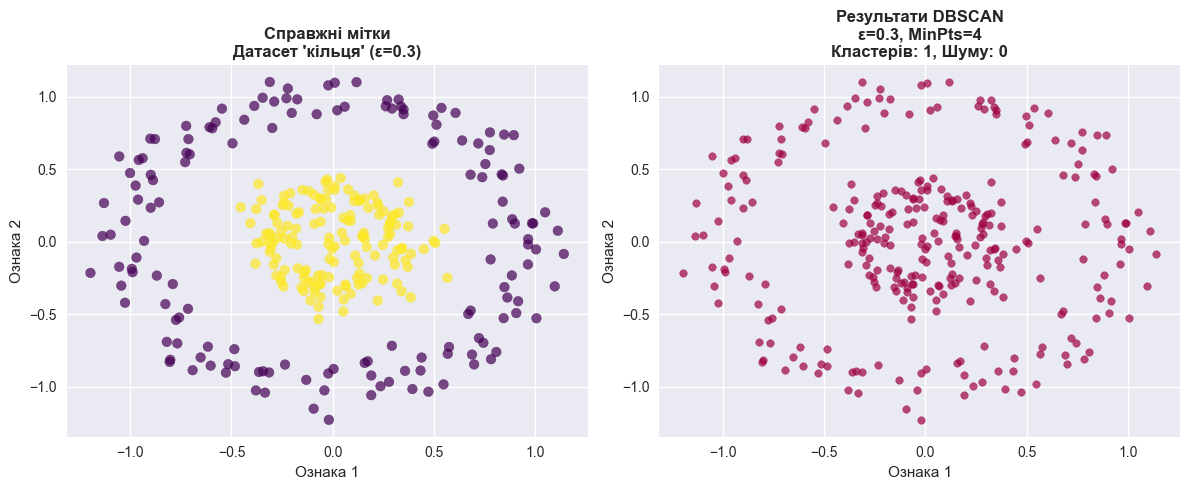

   Знайдено 1 кластерів і 0 шумових точок

Перевірка з ε = 0.4, MinPts = 4


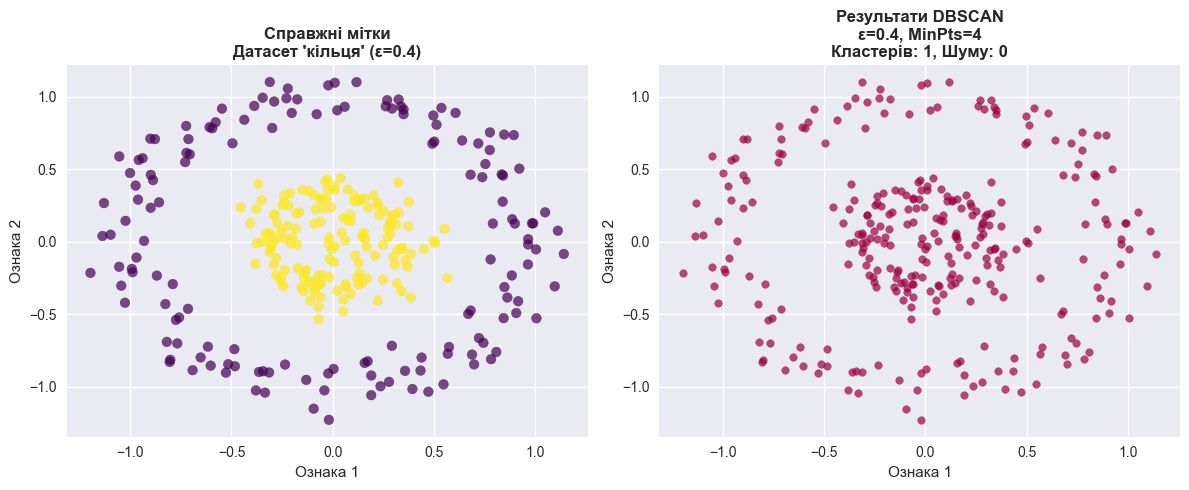

   Знайдено 1 кластерів і 0 шумових точок


In [6]:
print("\nПеревірка DBSCAN на датасеті 'кільця'")
print("=" * 50)

eps_values_circles = [0.1, 0.2, 0.3, 0.4]

for eps in eps_values_circles:
    print(f"\nПеревірка з ε = {eps}, MinPts = 4")
    labels, n_clusters, n_noise = apply_dbscan_and_visualize(
        X_circles, eps, 4, f"Датасет 'кільця' (ε={eps})", y_circles
    )
    print(f"   Знайдено {n_clusters} кластерів і {n_noise} шумових точок")


Перевірка DBSCAN на датасеті 'плями з шумом'

Перевірка з ε = 0.3, MinPts = 4


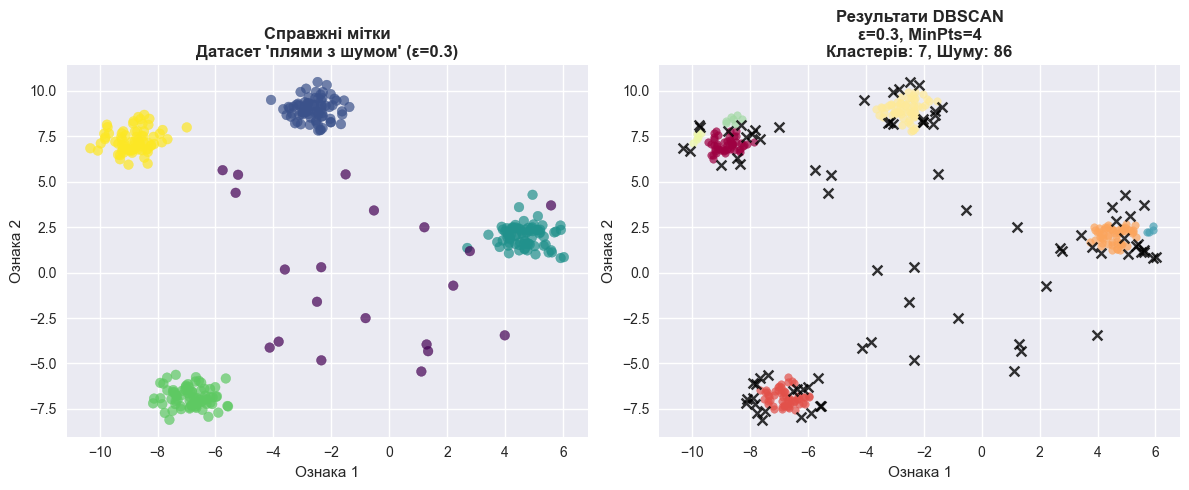

   Знайдено 7 кластерів і 86 шумових точок

Перевірка з ε = 0.5, MinPts = 4


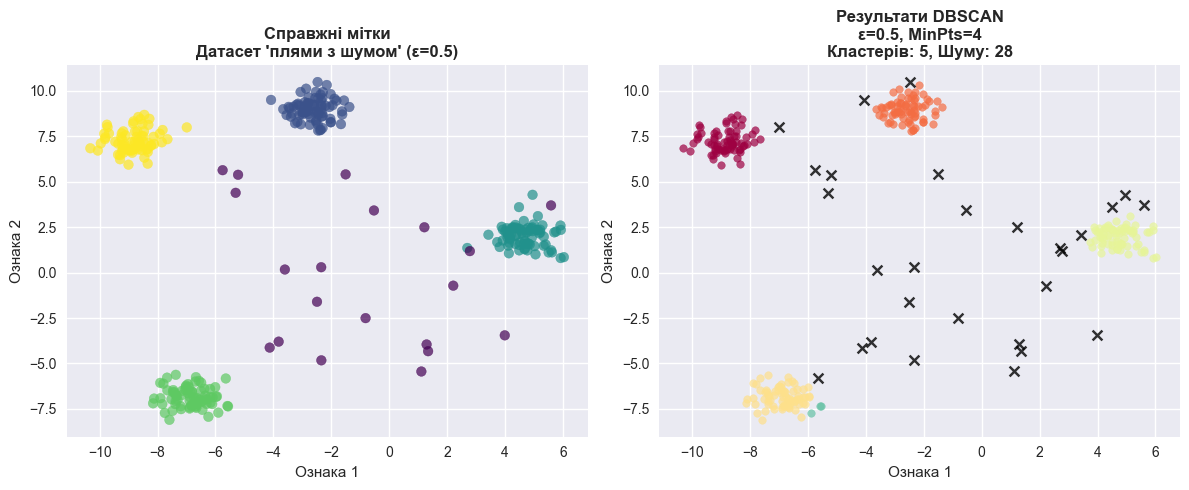

   Знайдено 5 кластерів і 28 шумових точок

Перевірка з ε = 0.7, MinPts = 4


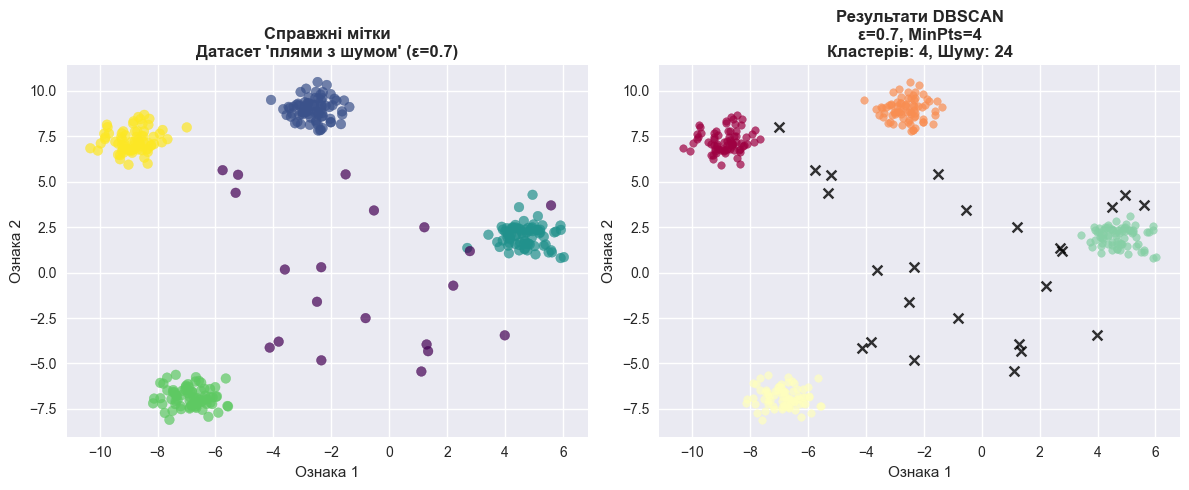

   Знайдено 4 кластерів і 24 шумових точок

Перевірка з ε = 1.0, MinPts = 4


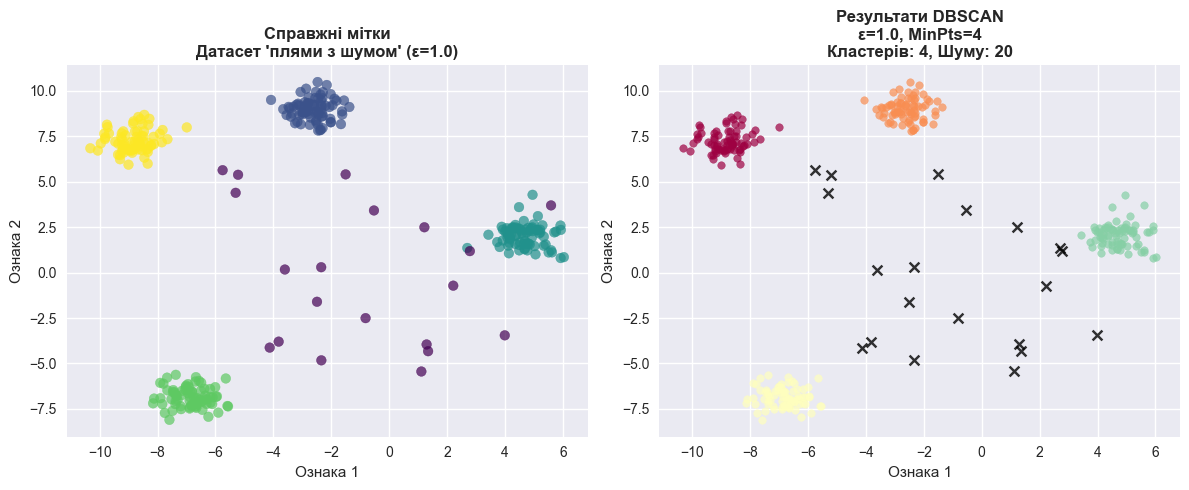

   Знайдено 4 кластерів і 20 шумових точок


In [7]:
print("\nПеревірка DBSCAN на датасеті 'плями з шумом'")
print("=" * 50)

eps_values_blobs = [0.3, 0.5, 0.7, 1.0]

for eps in eps_values_blobs:
    print(f"\nПеревірка з ε = {eps}, MinPts = 4")
    labels, n_clusters, n_noise = apply_dbscan_and_visualize(
        X_blobs, eps, 4, f"Датасет 'плями з шумом' (ε={eps})", y_blobs
    )
    print(f"   Знайдено {n_clusters} кластерів і {n_noise} шумових точок")

## OPTICS

**OPTICS** (Впорядкування точок для ідентифікації структури кластеризації) - це розширення DBSCAN, яке вирішує проблему чутливості до параметрів. Давайте детально дослідимо його ключові концепції.

### Основна відстань та відстань досяжності

Основа OPTICS полягає в двох ключових мірах відстані:

#### Основна відстань (Core Distance, CD)
Для точки p основна відстань визначається як:
$$CD(p) = \begin{cases} 
\text{невизначена} & \text{якщо } |N_{\varepsilon}(p)| < \text{MinPts} \\
\text{відстань до MinPts-го найближчого сусіда} & \text{якщо } |N_{\varepsilon}(p)| \geq \text{MinPts}
\end{cases}$$

**Ключові моменти:**
- Визначається лише для основних точок (точок з принаймні MinPts сусідами)
- Представляє мінімальне значення ε, для якого точка була б основною точкою
- Менша основна відстань = щільніша околиця

#### Відстань досяжності (Reachability Distance, RD)
Відстань досяжності від точки p до точки o:
$$RD(p,o) = \max(CD(p), \text{dist}(p,o))$$

**Ключові моменти:**
- Завжди визначена (на відміну від основної відстані)
- Представляє мінімальне значення ε, для якого o є безпосередньо досяжною за щільністю від p
- Якщо p не є основною точкою, RD(p,o) = ∞
- Якщо p є основною точкою, RD(p,o) = max(CD(p), відстань між p та o)

### Кроки алгоритму OPTICS

1. **Ініціалізація**: Встановити всі точки як необроблені
2. **Для кожної необробленої точки p**:
   - Позначити p як оброблену
   - Обчислити основну відстань CD(p)
   - Якщо CD(p) визначена (p є основною точкою):
     - Додати p до впорядкування
     - Для кожної необробленої точки q в N_ε(p):
       - Обчислити відстань досяжності RD(p,q)
       - Додати q до множини потенційних сусідів з пріоритетом RD(p,q)
     - Поки множина потенційних сусідів не порожня:
       - Витягти точку з мінімальною відстанню досяжності
       - Позначити як оброблену та додати до впорядкування
       - Якщо вона є основною точкою, обробити її сусідів

### Ключові переваги OPTICS

- **Стійкість до параметрів**: Менш чутливий до параметра ε, ніж DBSCAN
- **Ієрархічна структура**: Може витягувати кластери на різних рівнях щільності
- **Візуалізація**: Графік досяжності показує структуру кластеризації
- **Гнучкість**: Може витягувати кластери з різними порогами щільності

In [8]:
from sklearn.cluster import OPTICS

print("Реалізуємо алгоритм OPTICS")
print("=" * 40)

np.random.seed(42)

густий_кластер = np.random.normal([2, 2], 0.3, (100, 2))
середній_кластер = np.random.normal([-2, 2], 0.6, (80, 2))
розріджений_кластер = np.random.normal([0, -2], 1.0, (60, 2))
шум = np.random.uniform(-4, 4, (30, 2))

X_mixed_density = np.vstack([густий_кластер, середній_кластер, розріджений_кластер, шум])
y_mixed_density = np.hstack([np.zeros(100), np.ones(80), np.full(60, 2), np.full(30, -1)])

print(f"Створено датасет зі змішаною щільністю з {X_mixed_density.shape[0]} точками")
print("   • Густий кластер: 100 точок (std=0.3)")
print("   • Середній кластер: 80 точок (std=0.6)")
print("   • Розріджений кластер: 60 точок (std=1.0)")
print("   • Шум: 30 точок")

Реалізуємо алгоритм OPTICS
Створено датасет зі змішаною щільністю з 270 точками
   • Густий кластер: 100 точок (std=0.3)
   • Середній кластер: 80 точок (std=0.6)
   • Розріджений кластер: 60 точок (std=1.0)
   • Шум: 30 точок


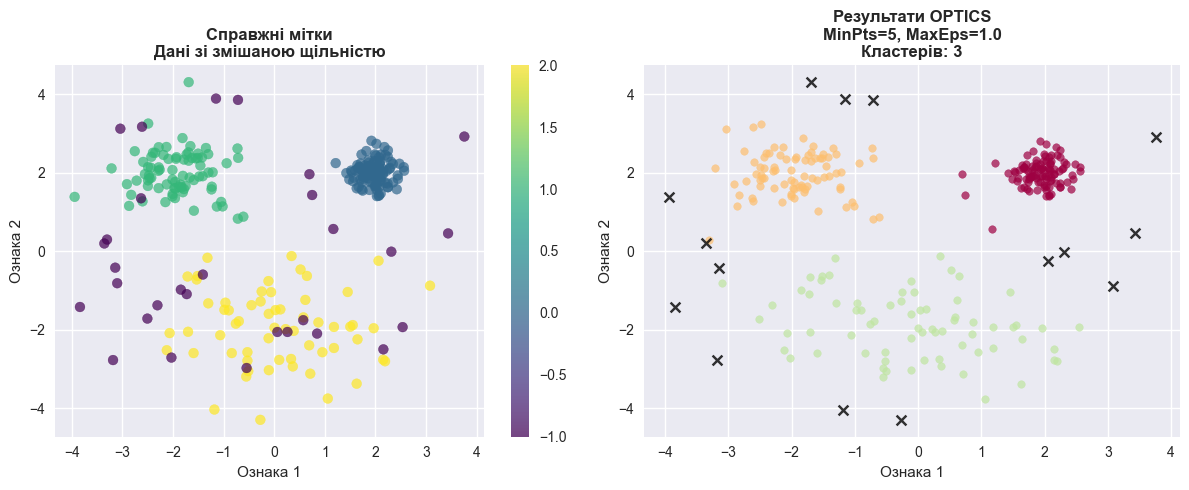

  Знайдено 3 кластерів та 15 шумових точок


In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_mixed_density[:, 0], X_mixed_density[:, 1], c=y_mixed_density, 
                     cmap='viridis', alpha=0.7, s=50)
plt.title('Справжні мітки\nДані зі змішаною щільністю', fontsize=12, fontweight='bold')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')
plt.colorbar(scatter)

plt.subplot(1, 2, 2)
max_eps = 1.0
optics = OPTICS(min_samples=5, max_eps=max_eps, cluster_method="dbscan")
optics_labels = optics.fit_predict(X_mixed_density)

unique_labels = set(optics_labels)
colors = plt.cm.Spectral(np.linspace(0, 1, len(unique_labels)))

for k, col in zip(unique_labels, colors):
    if k == -1:
        col = 'black'
        marker = 'x'
        size = 50
        alpha = 0.8
    else:
        marker = 'o'
        size = 30
        alpha = 0.7
        
    class_member_mask = (optics_labels == k)
    xy = X_mixed_density[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], c=[col], marker=marker, s=size, alpha=alpha)

plt.title(f'Результати OPTICS\nMinPts=5, MaxEps={max_eps}\nКластерів: {len(set(optics_labels))-1}', 
          fontsize=12, fontweight='bold')
plt.xlabel('Ознака 1')
plt.ylabel('Ознака 2')

plt.tight_layout()
plt.show()

print(f"  Знайдено {len(set(optics_labels))-1} кластерів та {list(optics_labels).count(-1)} шумових точок")

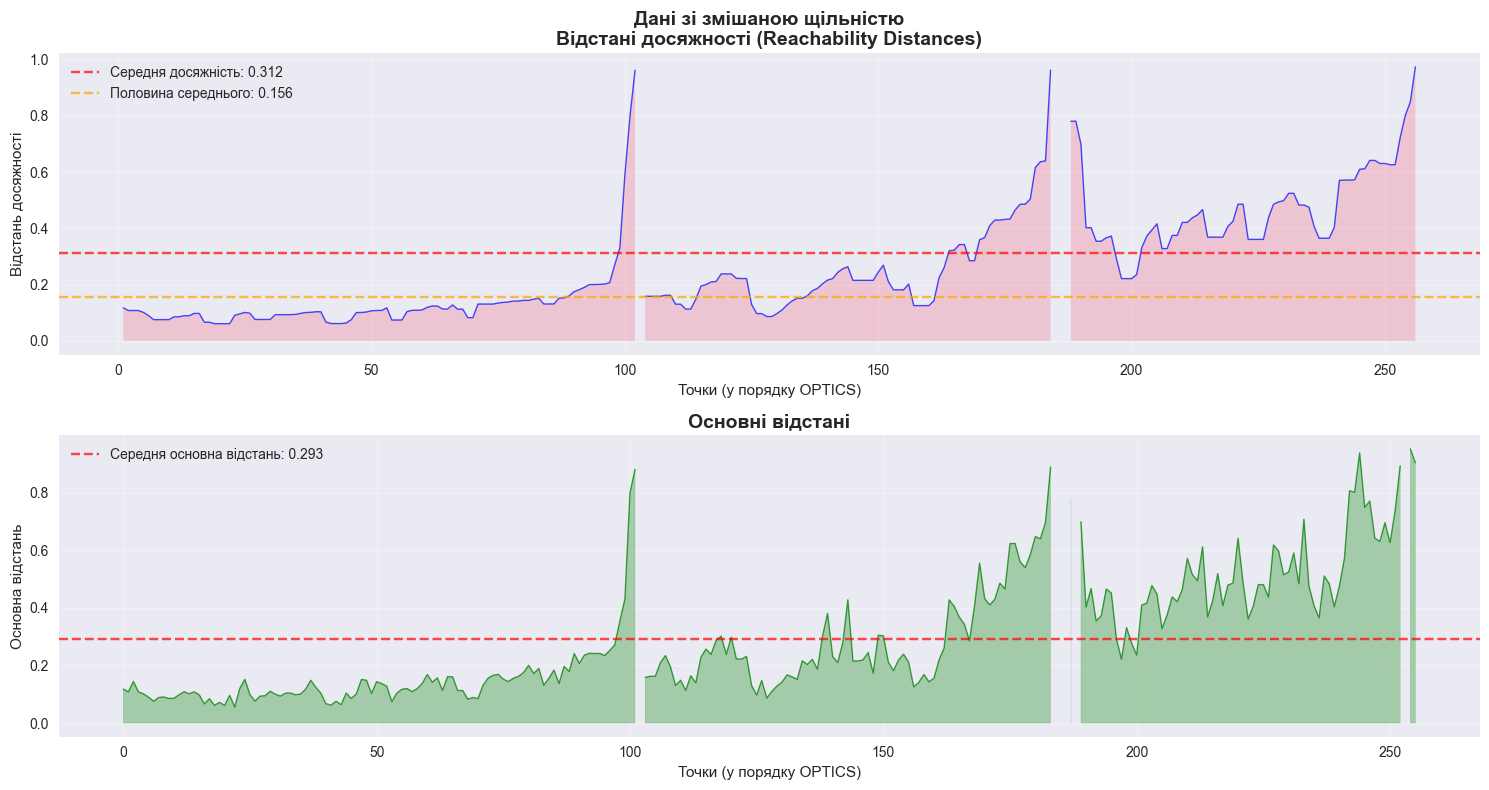

Аналіз reachability-графіка:
   • Середня відстань до досяжності: 0.312
   • Середня основна відстань: 0.293
   Впадини у графіку досяжності можуть визначати межі кластерів


In [10]:
def plot_reachability_plot(optics_model, title="Reachability-графік OPTICS"):
    """
    Побудувати reachability-графік для результатів OPTICS
    """
    ordering = optics_model.ordering_
    reachability = optics_model.reachability_[ordering]
    core_distances = optics_model.core_distances_[ordering]
    
    plt.figure(figsize=(15, 8))
    
    plt.subplot(2, 1, 1)
    plt.plot(range(len(reachability)), reachability, 'b-', linewidth=1, alpha=0.7)
    plt.fill_between(range(len(reachability)), reachability, alpha=0.3)
    plt.title(f'{title}\nВідстані досяжності (Reachability Distances)', fontsize=14, fontweight='bold')
    plt.xlabel('Точки (у порядку OPTICS)')
    plt.ylabel('Відстань досяжності')
    plt.grid(True, alpha=0.3)
    
    mean_reach = np.mean(np.clip(reachability, None, 1.0))
    
    plt.axhline(y=mean_reach, color='red', linestyle='--', alpha=0.7, 
                label=f'Середня досяжність: {mean_reach:.3f}')
    plt.axhline(y=mean_reach/2, color='orange', linestyle='--', alpha=0.7, 
                label=f'Половина середнього: {mean_reach/2:.3f}')
    
    plt.legend()
    
    plt.subplot(2, 1, 2)
    plt.plot(range(len(core_distances)), core_distances, 'g-', linewidth=1, alpha=0.7)
    plt.fill_between(range(len(core_distances)), core_distances, alpha=0.3, color='green')
    plt.title('Основні відстані', fontsize=14, fontweight='bold')
    plt.xlabel('Точки (у порядку OPTICS)')
    plt.ylabel('Основна відстань')
    plt.grid(True, alpha=0.3)
    
    mean_core = np.mean(core_distances[core_distances != np.inf])
    plt.axhline(y=mean_core, color='red', linestyle='--', alpha=0.7, 
                label=f'Середня основна відстань: {mean_core:.3f}')
    
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    print("Аналіз reachability-графіка:")
    print(f"   • Середня відстань до досяжності: {mean_reach:.3f}")
    print(f"   • Середня основна відстань: {mean_core:.3f}")
    print("   Впадини у графіку досяжності можуть визначати межі кластерів")

plot_reachability_plot(optics, "Дані зі змішаною щільністю")